# Install the Project requirements
this installs matplotlib and other necessary dependencies
you must have UV installed, use pip or your linux package manager

In [24]:
!uv sync

Resolved 52 packages in 1ms
Checked 46 packages in 0.65ms


# Get the data from the API
will request you to enter your secret key to get the data from the API
This will also import all required libaries

In [1]:
# Self coded tools for Data Exploration
from PreProcessing import PreProcess
from API import GovApi,Search
API = GovApi()
# Libaries for plotting data
import pandas as pd
import seaborn as sns
import matplotlib as plt

newSearch = Search()
newSearch.constituency = "Beaconsfield"

data = API.get_data(Search.path,**newSearch.params)
# data

200


# Data Pre-Processing

In [2]:
data_frame = pd.DataFrame(data['data'])
# data_frame.shape 678
data_frame = PreProcess.clean(data_frame)
data_frame = PreProcess.make_full_address(data_frame)
data_frame = PreProcess.drop_address_duplicates(data_frame)
# data_frame.shape 153

0


# Data Exploration

In [4]:
# First few columns
data_frame = data_frame.sort_values(by="currentEnergyEfficiencyBand")
data_frame.head()

,certificateNumber,addressLine1,addressLine2,addressLine3,addressLine4,postcode,postTown,council,constituency,currentEnergyEfficiencyBand,registrationDate,uprn,schemaType,FullAddress
23,2873-1010-5628-4590-6625,New Sports Hall,Sir William Borlase's Grammar School,"West Street,",NaN,SL7 2BR,Marlow,Buckinghamshire,Beaconsfield,A,2026-02-02,1.009653e+10,CEPC-8.0.0,New Sports Hall Sir William Borlase's Grammar ...
223,9997-0251-2119-8154-8890,The Beacon Centre,Beacon Close,NaN,NaN,HP9 1RJ,BEACONSFIELD,Buckinghamshire,Beaconsfield,A,2021-11-19,1.000812e+11,CEPC-8.0.0,The Beacon Centre Beacon Close
12,3542-6814-3342-2090-2592,Iver Heath Junior School,St Margaret's Close,Iver Heath,Buckinghamshire,SL0 0DA,Iver Heath,Buckinghamshire,Beaconsfield,B,2026-03-20,NaN,CEPC-8.0.0,Iver Heath Junior School St Margaret's Close I...
14,8026-9573-8017-0909-5623,Main Building (Front),Spinfield School,Terrington Hill,NaN,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2026-03-10,1.000813e+11,CEPC-8.0.0,Main Building (Front) Spinfield School Terring...
13,2575-1137-3963-2200-0691,Main Building (Rear),Spinfield School,Terrington Hill,NaN,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2026-03-10,1.000813e+11,CEPC-8.0.0,Main Building (Rear) Spinfield School Terringt...


In [5]:
# shape of the data (rows,columns)
data_frame.shape

(153, 14)

In [7]:
# testing postcodes pre processing
newSearch = Search()
newSearch.postcode = "SL7 2RE" # has multiple buildings and multiple certificates
data = API.get_data(Search.path,**newSearch.params)

test_data_frame = pd.DataFrame(data['data'])
PreProcess.clean(test_data_frame) # there are earlier certificates that show it having C effeciency instead of B

200
0


,certificateNumber,addressLine1,addressLine2,addressLine3,addressLine4,postcode,postTown,council,constituency,currentEnergyEfficiencyBand,registrationDate,uprn,schemaType
0,2575-1137-3963-2200-0691,Main Building (Rear),Spinfield School,Terrington Hill,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2026-03-10,100081278527,CEPC-8.0.0
1,8026-9573-8017-0909-5623,Main Building (Front),Spinfield School,Terrington Hill,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2026-03-10,100081278527,CEPC-8.0.0
2,2968-8515-4252-3592-6806,Spinfield School,Terrington Hill,NaN,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2025-02-11,100081278527,CEPC-8.0.0
3,0058-9210-3164-1316-1570,Spinfield School,Terrington Hill,NaN,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2024-05-07,100081278527,CEPC-8.0.0
4,9026-9238-2187-4884-6220,Spinfield School,Terrington Hill,NaN,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,B,2023-12-08,100081278527,CEPC-8.0.0
5,0979-6285-9122-0960-4230,Spinfield School,Terrington Hill,NaN,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,C,2022-03-11,100081278527,CEPC-8.0.0
6,6656-5819-8442-9297-4906,Spinfield School,Terrington Hill,NaN,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,C,2021-03-16,100081278527,CEPC-8.0.0
7,0220-2277-0160-5860-7080,NaN,Spinfield School,Terrington Hill,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,C,2020-02-28,100081278527,CEPC-7.1
8,0270-2977-0161-5660-7084,NaN,Spinfield School,Terrington Hill,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,C,2019-03-26,100081278527,CEPC-7.1
9,0620-0718-5769-8607-7002,NaN,Spinfield School,Terrington Hill,None,SL7 2RE,MARLOW,Buckinghamshire,Beaconsfield,C,2018-03-12,100081278527,CEPC-7.1


In [7]:
# check for missing values
data_frame.isnull().sum()

certificateNumber                0
addressLine1                    44
addressLine2                     1
addressLine3                    42
addressLine4                   116
postcode                         0
postTown                         0
council                          0
constituency                     0
currentEnergyEfficiencyBand      1
registrationDate                 0
uprn                             4
schemaType                       0
FullAddress                      0
dtype: int64

<Axes: xlabel='currentEnergyEfficiencyBand', ylabel='percent'>

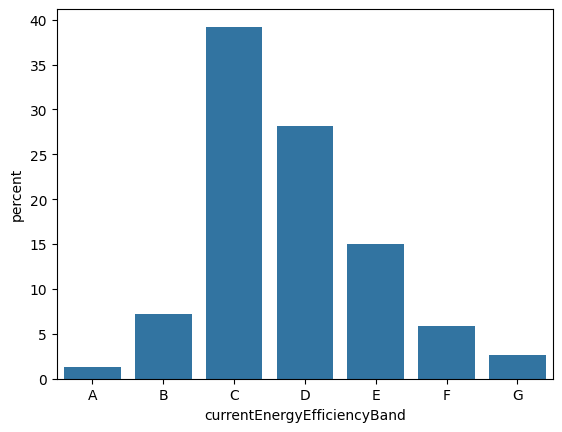

In [8]:

# check distribution of target variable
sns.countplot(data=data_frame, x="currentEnergyEfficiencyBand", stat="percent")

# Compare the constituency Beaconsfield to London

In [ ]:
newSearch = Search()
newSearch.constituency = "Cities of London and Westminster"

data = API.get_data(Search.path,**newSearch.params)
next_data_frame = PreProcess.clean(pd.DataFrame(data['data']))

next_data_frame = PreProcess.make_full_address()
next_data_frame = PreProcess.drop_address_duplicates()


200
0


In [10]:
# London Shape
next_data_frame.shape

(993, 14)

In [11]:
next_data_frame.isnull().sum()

certificateNumber                0
addressLine1                   419
addressLine2                    55
addressLine3                   368
addressLine4                   920
postcode                         0
postTown                         0
council                          0
constituency                     0
currentEnergyEfficiencyBand      6
registrationDate                 0
uprn                           151
schemaType                       0
FullAddress                      0
dtype: int64

<Axes: xlabel='currentEnergyEfficiencyBand', ylabel='percent'>

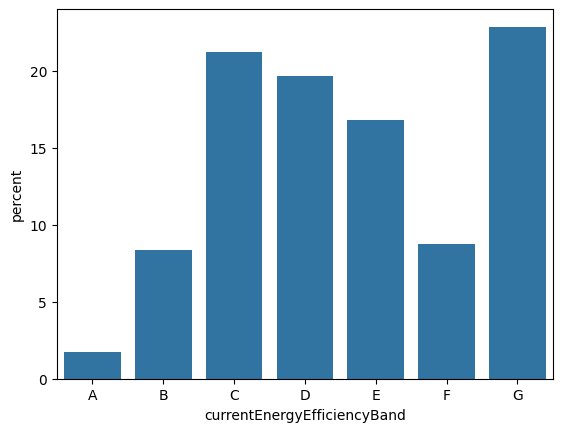

In [12]:
sns.countplot(data=next_data_frame.sort_values(by="currentEnergyEfficiencyBand"), x="currentEnergyEfficiencyBand", stat="percent")

In [13]:
# sub-urban vs urban data 
full_data = pd.concat([data_frame,next_data_frame],ignore_index=True).sort_values(by="currentEnergyEfficiencyBand")
full_data.shape

(1146, 14)

<Axes: xlabel='currentEnergyEfficiencyBand', ylabel='proportion'>

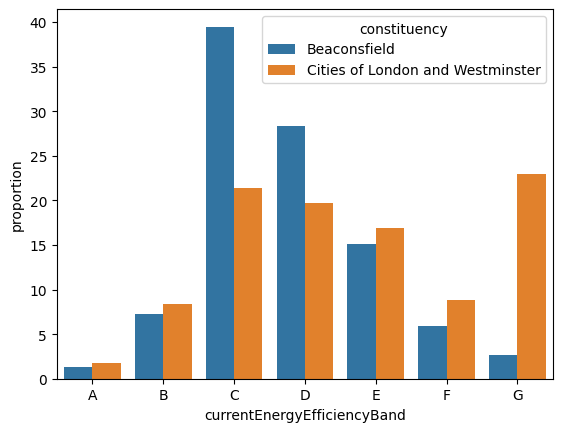

In [14]:
# Make beaconsfield proportionate to london to do an efficiency comparison
comparison = full_data.groupby("constituency")["currentEnergyEfficiencyBand"].value_counts(normalize=True).mul(100).sort_index().reset_index().sort_values(by="currentEnergyEfficiencyBand")

sns.barplot( data=comparison, x="currentEnergyEfficiencyBand", y="proportion", hue="constituency")
# sns.countplot(data=new, x="currentEnergyEfficiencyBand", stat="percent",hue="constituency")

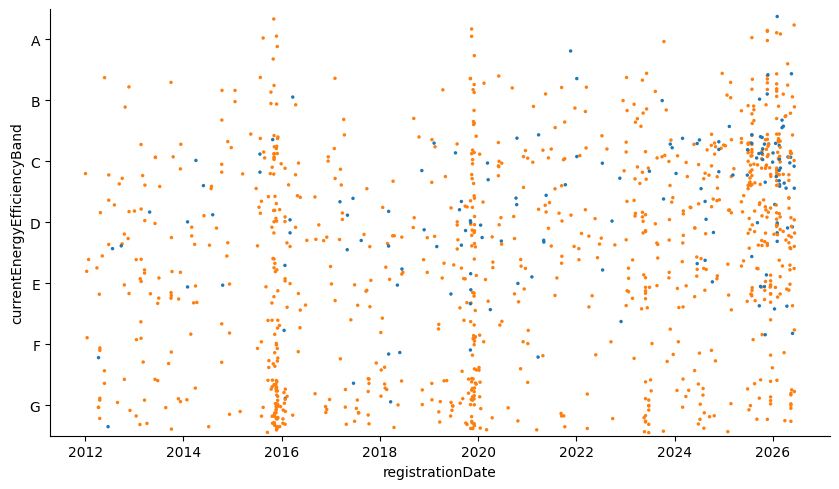

In [ ]:
# Are buildings that have registered earlier more or less energy efficent?

full_data["registrationDate"] = pd.to_datetime(full_data["registrationDate"])
full_data["registrationYear"] = full_data["registrationDate"].dt.year
table = sns.catplot(
    data=full_data,
    x="registrationDate", 
    y="currentEnergyEfficiencyBand", 
    native_scale=True,
    jitter=0.45,
    kind="strip",
    hue="constituency",
    size=2.5,
    legend=False,
    aspect=1.7
)

table

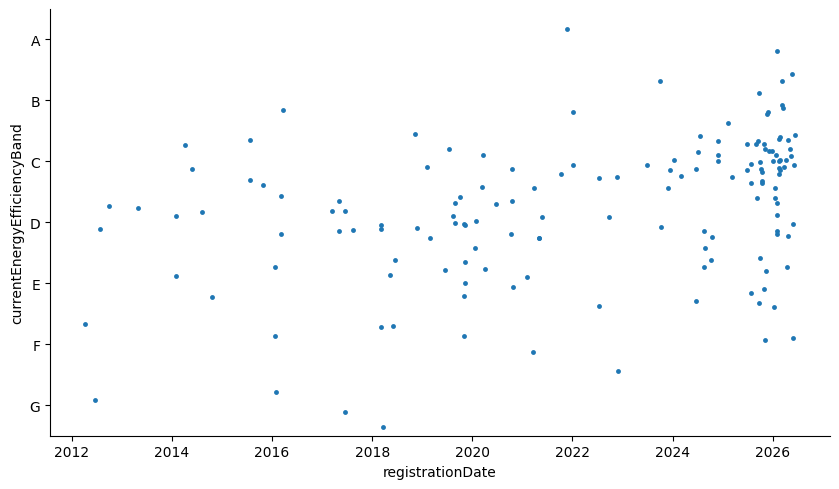

In [ ]:
# beaconsfield only

data_frame["registrationDate"] = pd.to_datetime(data_frame["registrationDate"])
data_frame["registrationYear"] = data_frame["registrationDate"].dt.year
table = sns.catplot(
    data=data_frame,
    x="registrationDate", 
    y="currentEnergyEfficiencyBand", 
    native_scale=True,
    jitter=0.45,
    kind="strip",
    size=3.5,
    legend=False,
    aspect=1.7
)

# Feature Engineering with NLP
This first step is to download and install all nltk and spacy requirements

In [32]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
!uv pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0.tar.gz

import spacy
NLP = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to /home/silent/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/silent/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Checked 1 package in 1ms


In [ ]:
# print(hasattr(PreProcess, "remove_stopwords"))
# print(dir(PreProcess))

data_frame['tokens'] = data_frame["FullAddress"].apply(PreProcess.remove_stopwords)

all_buildings = data_frame['tokens'].dropna().tolist()

from nltk import ngrams

N = 2 

for buildings in all_buildings :

    # Generate Bi-grams
    n_grams = list(ngrams(buildings, N))
    # tagged = list(pos_tag(buildings)) cant differentiate meaning
  



peters catholic -> ORG
catholic primary -> ORG
primary school -> ORG
vale school -> ORG
school farnham -> ORG
farnham road -> ORG
hollybush hill -> ORG
juniper hill -> ORG
hill school -> ORG
block st -> ORG
st pauls -> ORG
pauls c -> ORG
farnham common -> ORG
common junior -> ORG
junior school -> ORG
burnham health -> ORG
health centre -> ORG
centre minniecroft -> ORG
minniecroft road -> ORG
school terrington -> ORG
terrington hill -> ORG
st nicolas -> PERSON
denham green -> ORG
theatre building -> PERSON
william borlases -> PERSON
grammar school -> ORG
school west -> ORG
west street -> ORG
new sports -> ORG
sports hall -> ORG
william borlases -> PERSON
grammar school -> ORG
school west -> ORG
west street -> ORG
william borlases -> PERSON
grammar school -> ORG
school west -> ORG
west street -> ORG
william borlases -> PERSON
grammar school -> ORG
school west -> ORG
west street -> ORG
william borlases -> PERSON
grammar school -> ORG
school west -> ORG
west street -> ORG
burnham grammar -